In [4]:
from pathlib import Path
from math import ceil
from glob import glob
import nibabel as nib
import numpy as np
from nilearn import plotting
from nilearn.image import load_img
from templateflow import api as tflow
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [6]:
# ------------------------------------------------------------------
# Inputs
# ------------------------------------------------------------------
mask_files_nobbr = sorted(
    glob(
        "/Volumes/research/LU26D1023-DemonLab/DemonLab/ROSMAP/derivatives/BNK_1.3/fmriprep/unzipped/sub-*/**/sub-*/ses-*/func/*MNI*brain_mask.nii.gz"
    )
)

if not mask_files_nobbr:
    raise RuntimeError("No masks found")

print(f"Found {len(mask_files_nobbr):,} masks in {mask_files_nobbr}")

mask_files_bbr = sorted(
    glob(
        "/Volumes/research/LU26D1023-DemonLab/DemonLab/ROSMAP/derivatives/fmriprep/unzipped/sub-*/**/sub-*/ses-*/func/*BNK*MNI*brain_mask.nii.gz"
    )
)

if not mask_files_bbr:
    raise RuntimeError("No masks found")

print(f"Found {len(mask_files_bbr):,} masks in {mask_files_bbr}")

Found 647 masks in ['/Volumes/research/LU26D1023-DemonLab/DemonLab/ROSMAP/derivatives/BNK_1.3/fmriprep/unzipped/sub-00709354_ses-0_fmriprep-25-2-5/fmriprep/sub-00709354/ses-0/func/sub-00709354_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz', '/Volumes/research/LU26D1023-DemonLab/DemonLab/ROSMAP/derivatives/BNK_1.3/fmriprep/unzipped/sub-00709354_ses-1_fmriprep-25-2-5/fmriprep/sub-00709354/ses-1/func/sub-00709354_ses-1_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz', '/Volumes/research/LU26D1023-DemonLab/DemonLab/ROSMAP/derivatives/BNK_1.3/fmriprep/unzipped/sub-00807897_ses-1_fmriprep-25-2-5/fmriprep/sub-00807897/ses-1/func/sub-00807897_ses-1_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz', '/Volumes/research/LU26D1023-DemonLab/DemonLab/ROSMAP/derivatives/BNK_1.3/fmriprep/unzipped/sub-01626306_ses-0_fmriprep-25-2-5/fmriprep/sub-01626306/ses-0/func/sub-01626306_ses-0_task-rest_ac

In [8]:
# ------------------------------------------------------------------
# Files and MNI152NLin6Asym reference
# ------------------------------------------------------------------

mni_t1 = load_img(tflow.get(
    "MNI152NLin6Asym",
    resolution=2,
    suffix="T1w",
    desc="brain",
    extension="nii.gz",
))

mni_brain_mask = load_img(tflow.get(
    "MNI152NLin6Asym",
    resolution=2,
    suffix="mask",
    desc="brain",
    extension="nii.gz",
))

mni_brain = mni_brain_mask.get_fdata() > 0.5

In [9]:
def plot_alignment_epi(
    mni_t1,
    mni_brain_mask,
    mask_files,
    label,
    #title="EPI-derived brain-mask alignment",
    bad_overlap_threshold=0.80,
    figsize=(18, 9),
):
    mask_files = list(mask_files)

    mni_brain = mni_brain_mask.get_fdata() > 0.5
    count = np.zeros(mni_t1.shape, dtype=np.uint16)

    bad_masks = []
    empty_masks = []
    overlap_results = []

    for i, filename in enumerate(mask_files, start=1):
        img = load_img(filename)

        if img.shape != mni_t1.shape:
            raise ValueError(
                f"Shape mismatch for {filename}: "
                f"{img.shape} != {mni_t1.shape}"
            )

        if not np.allclose(img.affine, mni_t1.affine):
            raise ValueError(f"Affine mismatch for {filename}")

        epi = img.get_fdata() > 0.5
        epi_size = np.count_nonzero(epi)

        if epi_size == 0:
            empty_masks.append(filename)
            overlap_results.append((filename, np.nan))
            continue

        count += epi

        coverage = np.count_nonzero(epi & mni_brain) / epi_size
        overlap_results.append((filename, coverage))

        if coverage < bad_overlap_threshold:
            bad_masks.append((filename, coverage, img))

        if i % 100 == 0:
            print(f"Processed {i:,}/{len(mask_files):,}")

    n_valid = len(mask_files) - len(empty_masks)

    if n_valid == 0:
        raise ValueError("All input masks are empty")

    thresholds = {
        "85%": ceil(0.85 * n_valid),
        "95%": ceil(0.95 * n_valid),
        "99%": ceil(0.99 * n_valid),
    }

    group_masks = {
        threshold_name: nib.Nifti1Image(
            (count >= required).astype(np.uint8),
            mni_t1.affine,
            mni_t1.header.copy(),
        )
        for threshold_name, required in thresholds.items()
    }

    styles = {
        "85%": ("blue", 2.5),
        "95%": ("purple", 2.5),
        "99%": ("black", 3.0),
    }

    # Create a larger Matplotlib figure
    fig = plt.figure(figsize=figsize)

    display = plotting.plot_anat(
        mni_t1,
        figure=fig,
        display_mode="ortho",
        cut_coords=(0, -20, 10),
        title=None,
        annotate=True,
        draw_cross=False,
        colorbar=False
    )

    # Use a larger figure-level title
    # fig.suptitle(
    #     (
    #         f"{title}\n"
    #         f"{label}: {len(bad_masks):,} masks with "
    #         f"<{bad_overlap_threshold:.0%} MNI-brain coverage"
    #     ),
    #     fontsize=20,
    #     color="white",
    #     fontweight="bold",
    #     y=0.98,
    # )

    # Individual badly aligned masks
    for _, _, bad_img in bad_masks:
        display.add_contours(
            bad_img,
            levels=[0.5],
            colors=["red"],
            linewidths=0.8,
            transparency=0.6,
        )

    plotted_thresholds = []

    # Group-level contours
    for threshold_name, image in group_masks.items():
        if not np.any(image.get_fdata()):
            print(f"{threshold_name} contour is empty; omitted")
            continue

        color, width = styles[threshold_name]

        display.add_contours(
            image,
            levels=[0.5],
            colors=[color],
            linewidths=width,
        )

        plotted_thresholds.append(threshold_name)

    # Nilearn does not automatically make legends for contours,
    # so construct one using proxy lines.
    legend_handles = []

    if bad_masks:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="red",
                linewidth=2,
                alpha=0.6,
                label=(
                    "Individual masks with "
                    f"<{bad_overlap_threshold:.0%} "
                    "MNI-brain coverage"
                ),
            )
        )

    legend_text = {
        "85%": "Voxels present in ≥85% of valid masks",
        "95%": "Voxels present in ≥95% of valid masks",
        "99%": "Voxels present in ≥99% of valid masks",
    }

    for threshold_name in plotted_thresholds:
        color, width = styles[threshold_name]

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linewidth=width,
                label=legend_text[threshold_name],
            )
        )

    # if legend_handles:
    #     fig.legend(
    #         handles=legend_handles,
    #         loc="lower center",
    #         bbox_to_anchor=(0.5, 0.02),
    #         ncol=2,
    #         fontsize=14,
    #         frameon=True,
    #         fancybox=True,
    #         framealpha=0.95,
    #     )

    # Reserve space for title and legend
    fig.subplots_adjust(
        top=0.82,
        bottom=0.20,
        left=0.02,
        right=0.98,
    )

    plotting.show()

    return overlap_results, bad_masks, empty_masks, group_masks

Processed 100/648
Processed 200/648
Processed 300/648
Processed 400/648
Processed 500/648
Processed 600/648


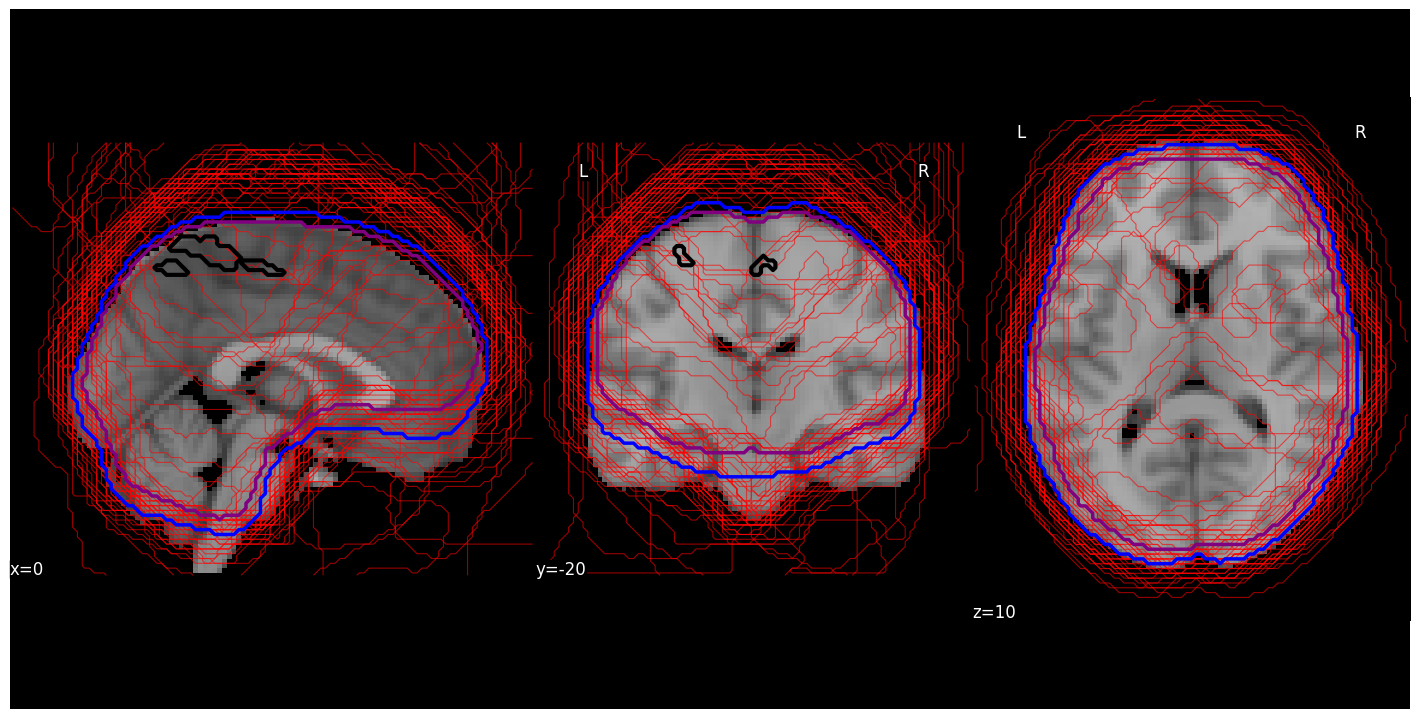

In [10]:
results_bbr = plot_alignment_epi(
    mni_t1=mni_t1,
    mni_brain_mask=mni_brain_mask,
    mask_files=mask_files_bbr,
    label="BBR",
    bad_overlap_threshold=0.80,
    figsize=(14, 7),
    #title="Overlap of EPI-Derived Brain Masks in MNI Space for BNK site (BBR)",
)

Processed 100/647
Processed 200/647
Processed 300/647
Processed 400/647
Processed 500/647
Processed 600/647


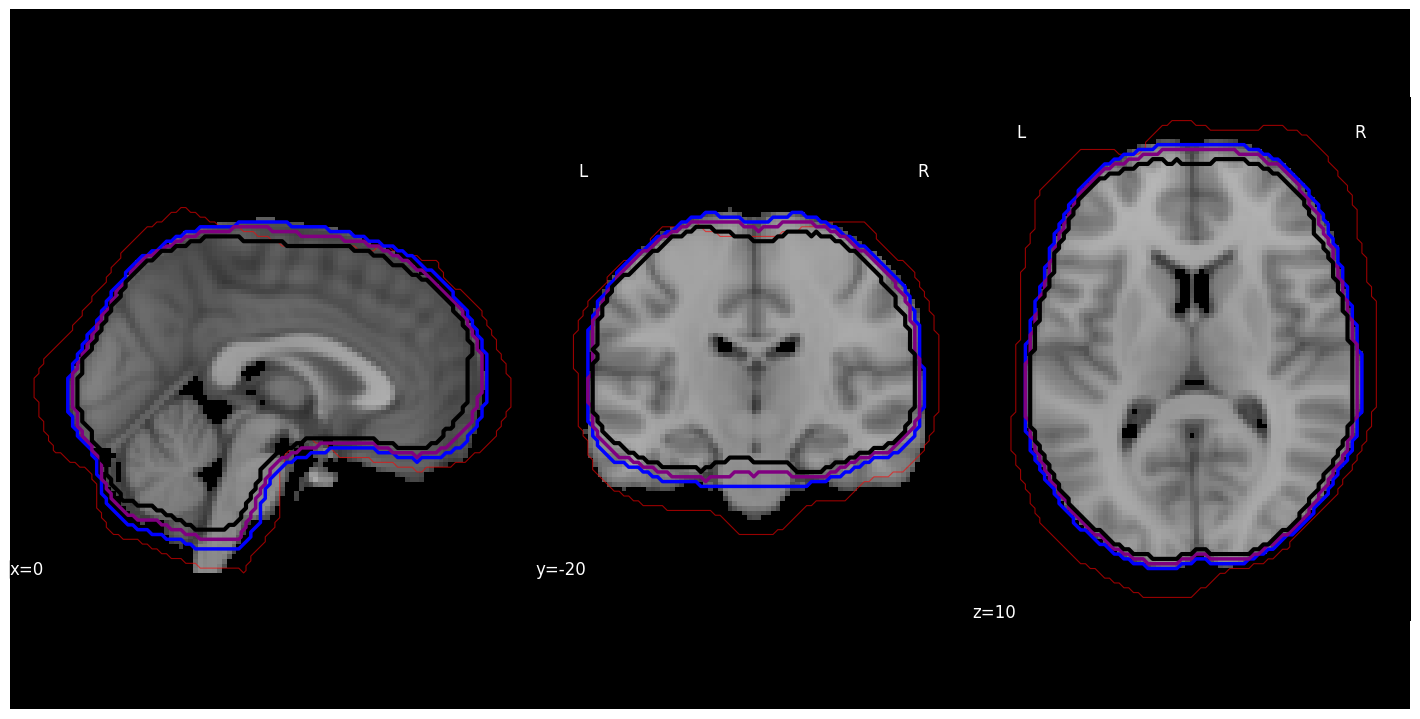

In [11]:
results_nobbr = plot_alignment_epi(
    mni_t1=mni_t1,
    mni_brain_mask=mni_brain_mask,
    mask_files=mask_files_nobbr,
    label="No BBR",
    bad_overlap_threshold=0.80,
    figsize=(14, 7),
    #title="Overlap of EPI-Derived Brain Masks in MNI Space for BNK site (noBBR)",
)

In [140]:
overlap_results, bad_masks, empty_masks, group_masks = results_nobbr

worst = sorted(
    [
        (filename, coverage)
        for filename, coverage in overlap_results
        if not np.isnan(coverage)
    ],
    key=lambda item: item[1],
)

for filename, coverage in worst[:20]:
    print(f"{coverage:.1%}  {filename.split('/')[-1]}")

78.1%  sub-27083391_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
80.5%  sub-84248280_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
81.6%  sub-87821751_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
82.4%  sub-92371267_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
82.8%  sub-34204855_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
84.2%  sub-24051131_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
84.3%  sub-76137867_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
84.3%  sub-85925902_ses-0_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
84.3%  sub-85925902_ses-1_task-rest_acq-BNK20090211rfMRI_space-MNI152NLin6Asym_res-2_desc-brain_mask.nii.gz
84.6%  sub-69660076_ses-0_ta

In [29]:
from pathlib import Path

import nibabel as nib

from nireports.reportlets.mosaic import plot_registration
from nireports.reportlets.utils import compose_view


def make_coreg_report_exact(
    t1w_file,
    bold_in_t1w_file,
    output_svg,
    cuts,
    wm_contour_file=None,
    axes=("z", "x", "y"),
    show_annotations=False,
):
    """
    Create an fMRIPrep-style coregistration SVG with exact slice positions.

    Parameters
    ----------
    cuts : dict
        Exact world-space coordinates in millimetres, for example:
        {
            "x": [-40, -20, 0, 20, 40],
            "y": [-60, -30, 0, 30],
            "z": [-20, 0, 20, 40, 60],
        }

    axes : tuple
        Axes to display and their vertical order.
        "x" = sagittal
        "y" = coronal
        "z" = axial

    show_annotations : bool
        Whether to display Nilearn's L/R and coordinate annotations.
    """
    output = Path(output_svg).expanduser().resolve()
    output.parent.mkdir(parents=True, exist_ok=True)

    t1w = nib.load(str(Path(t1w_file).expanduser().resolve()))
    boldref = nib.load(
        str(Path(bold_in_t1w_file).expanduser().resolve())
    )

    contour = None
    if wm_contour_file:
        contour = nib.load(
            str(Path(wm_contour_file).expanduser().resolve())
        )

    axes = tuple(axes)

    missing = [axis for axis in axes if axis not in cuts]
    if missing:
        raise ValueError(
            f"No cut coordinates supplied for axes: {missing}"
        )

    plot_params = {
        # False removes L/R and coordinate text.
        "annotate": show_annotations,
    }

    t1w_panels = plot_registration(
        anat_nii=t1w,
        div_id="fixed-image",
        plot_params=plot_params.copy(),
        order=axes,
        cuts=cuts,
        estimate_brightness=True,

        # None removes the T1w/BOLD title or "legend".
        label=None,

        contour=contour,
        compress=False,
    )

    bold_panels = plot_registration(
        anat_nii=boldref,
        div_id="moving-image",
        plot_params=plot_params.copy(),
        order=axes,
        cuts=cuts,
        estimate_brightness=True,
        label=None,
        contour=contour,
        compress=False,
    )

    compose_view(
        bg_svgs=t1w_panels,
        fg_svgs=bold_panels,
        out_file=str(output),
    )

    return output

In [30]:
cuts = {
    # Sagittal slices, left to right
    "x": [33, 24, 15, 7, -2, -10, -18],

    # Coronal slices, posterior to anterior
    "y": [-55, -42, -29, -16, -2, 10, 23],

    # Axial slices, inferior to superior
    "z": [-71, -54, -37, -21, -4, 11, 28],
}

report = make_coreg_report_exact(
    t1w_file=(
        "/Users/ga0034de/Desktop/omni_x/"
        "sub-32514566_ses-2_space-bold_desc-preproc_T1w.nii.gz"
    ),
    bold_in_t1w_file=(
        "/Users/ga0034de/Desktop/omni_x/"
        "sub-32514566_ses-2_task-rest_acq-UC20220419EPIdc_"
        "desc-coreg_boldref.nii.gz"
    ),
    wm_contour_file=(
        "/Users/ga0034de/Desktop/omni_x/sub-32514566_ses-2_space-bold_label-WM_probseg.nii.gz"
    ),
    output_svg=(
        "/Users/ga0034de/Desktop/omni_x/sub-32514566_ses-2_generated_task-rest_desc-coreg_bold.svg"
    ),
    cuts=cuts,
    axes=("z", "x", "y"),
    show_annotations=False,
)

print(report)

/Users/ga0034de/Desktop/omni_x/sub-32514566_ses-2_generated_task-rest_desc-coreg_bold.svg
